In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.warp import reproject, Resampling
from rasterio.plot import show
from skimage.draw import line
from rasterio import open as rio_open
from scipy.signal import savgol_filter
from PIL import Image
import pandas as pd

In [2]:
# Function to read the image using rasterio
def read_image(tif_path):
    #with rasterio.open(image_path) as dataset:
    with rasterio.open(tif_path) as src:
        image = src.read(1)
        transform = src.transform  # Get geotransform
        crs = src.crs  # Get coordinate reference system
        bounds = src.bounds  # Get bounding box
    return image, transform, crs, bounds


def extract_line_profile(tif_path, start_point_geo, end_point_geo, plot_line=True):
    """
    Extract the profile line from a TIFF file and optionally plot the line on the image.
    
    Parameters:
        tif_path (str): Path to the TIFF file.
        start_point_geo (tuple): Starting point in georeferenced coordinates (easting, northing).
        end_point_geo (tuple): Ending point in georeferenced coordinates (easting, northing).
        plot_line (bool): Whether to plot the line on the image. Default is True.
    
    Returns:
        numpy.ndarray: Pixel values along the profile line.
    """
    with rasterio.open(tif_path) as src:
        band = src.read(1)  # Read the first (or only) band
        transform = src.transform  # Get geotransform
        crs = src.crs  # Get coordinate reference system

    # Convert georeferenced coordinates to pixel coordinates
    start_point_pixel = ~transform * start_point_geo  # (col, row)
    end_point_pixel = ~transform * end_point_geo  # (col, row)
    """
    # Round to nearest integer for pixel indices
    #Rounding to the nearest integer is a critical step when converting 
    georeferenced coordinates to pixel indices. It ensures that:

    # The indices are valid integers.
    
    # The correct pixel is selected.
    
    # No IndexError is raised.
    """
    # Round to nearest integer for pixel indices
    start_point_pixel = (int(round(start_point_pixel[1])), int(round(start_point_pixel[0])))  # (row, col)
    end_point_pixel = (int(round(end_point_pixel[1])), int(round(end_point_pixel[0])))  # (row, col)

    # Get line indices
    rr, cc = line(start_point_pixel[0], start_point_pixel[1], end_point_pixel[0], end_point_pixel[1])

    # Extract pixel values along the line
    profile_values = band[rr, cc]
    return profile_values

# Function to normalize the image
def normalize(array):
    """
    Normalize an array to the range [0, 1].
    
    Parameters:
        array (numpy.ndarray): Input 2D array.
    
    Returns:
        numpy.ndarray: Normalized array.
    """
    array_min, array_max = array.min(), array.max()
    return (array - array_min) / (array_max - array_min)

# Function to extract profile line values from a raster
def extract_normlized_line_profile(tif_path, start_point_geo, end_point_geo):
    with rasterio.open(tif_path) as src:
        band = src.read(1)  # Read the first (or only) band
        band_norm = 1- normalize(band)
        transform = src.transform  # Get geotransform
        crs = src.crs  # Get coordinate reference system
    # Convert georeferenced coordinates to pixel coordinates
    start_point_pixel = ~transform * start_point_geo  # (col, row)
    end_point_pixel = ~transform * end_point_geo  # (col, row)

    # Round to nearest integer for pixel indices
    start_point_pixel = (int(round(start_point_pixel[1])), int(round(start_point_pixel[0])))  # (row, col)
    end_point_pixel = (int(round(end_point_pixel[1])), int(round(end_point_pixel[0])))  # (row, col)

    # Get line indices
    rr, cc = line(start_point_pixel[0], start_point_pixel[1], end_point_pixel[0], end_point_pixel[1])

    # Extract pixel values along the line
    profile_values = band_norm[rr, cc]
    return profile_values


def smooth_data(data, window_size=101, polyorder=2): 
    return savgol_filter(data, window_size, polyorder)


def process_tif_paths(tif_path, start_point, end_point):
    """
    Processes a list of TIF file paths to extract, invert, smooth,
    and return the line profile data.

    Args:
        tif_paths (list): List of file paths to TIF files.
        start_point (tuple): Starting point for line profile extraction.
        end_point (tuple): Ending point for line profile extraction.

    Returns:
        list: A list of smoothed and inverted line profile values.
    """
     # Extract line profile data
    values = extract_normlized_line_profile(tif_path, start_point, end_point)
    inverted_values = values  # Reverse convexity
    smoothed_values = smooth_data(inverted_values)  # Smooth the data
    return smoothed_values

Start Point (Easting, Northing): (426500, 7088000)
End Point (Easting, Northing): (428000, 7079500)


C:\Users\Mohannad Zahra\AppData\Local\Temp\ipykernel_18636\3793636378.py:182: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.05, 0.07, 0.92, 0.98])  # more padding for titles/colorbars


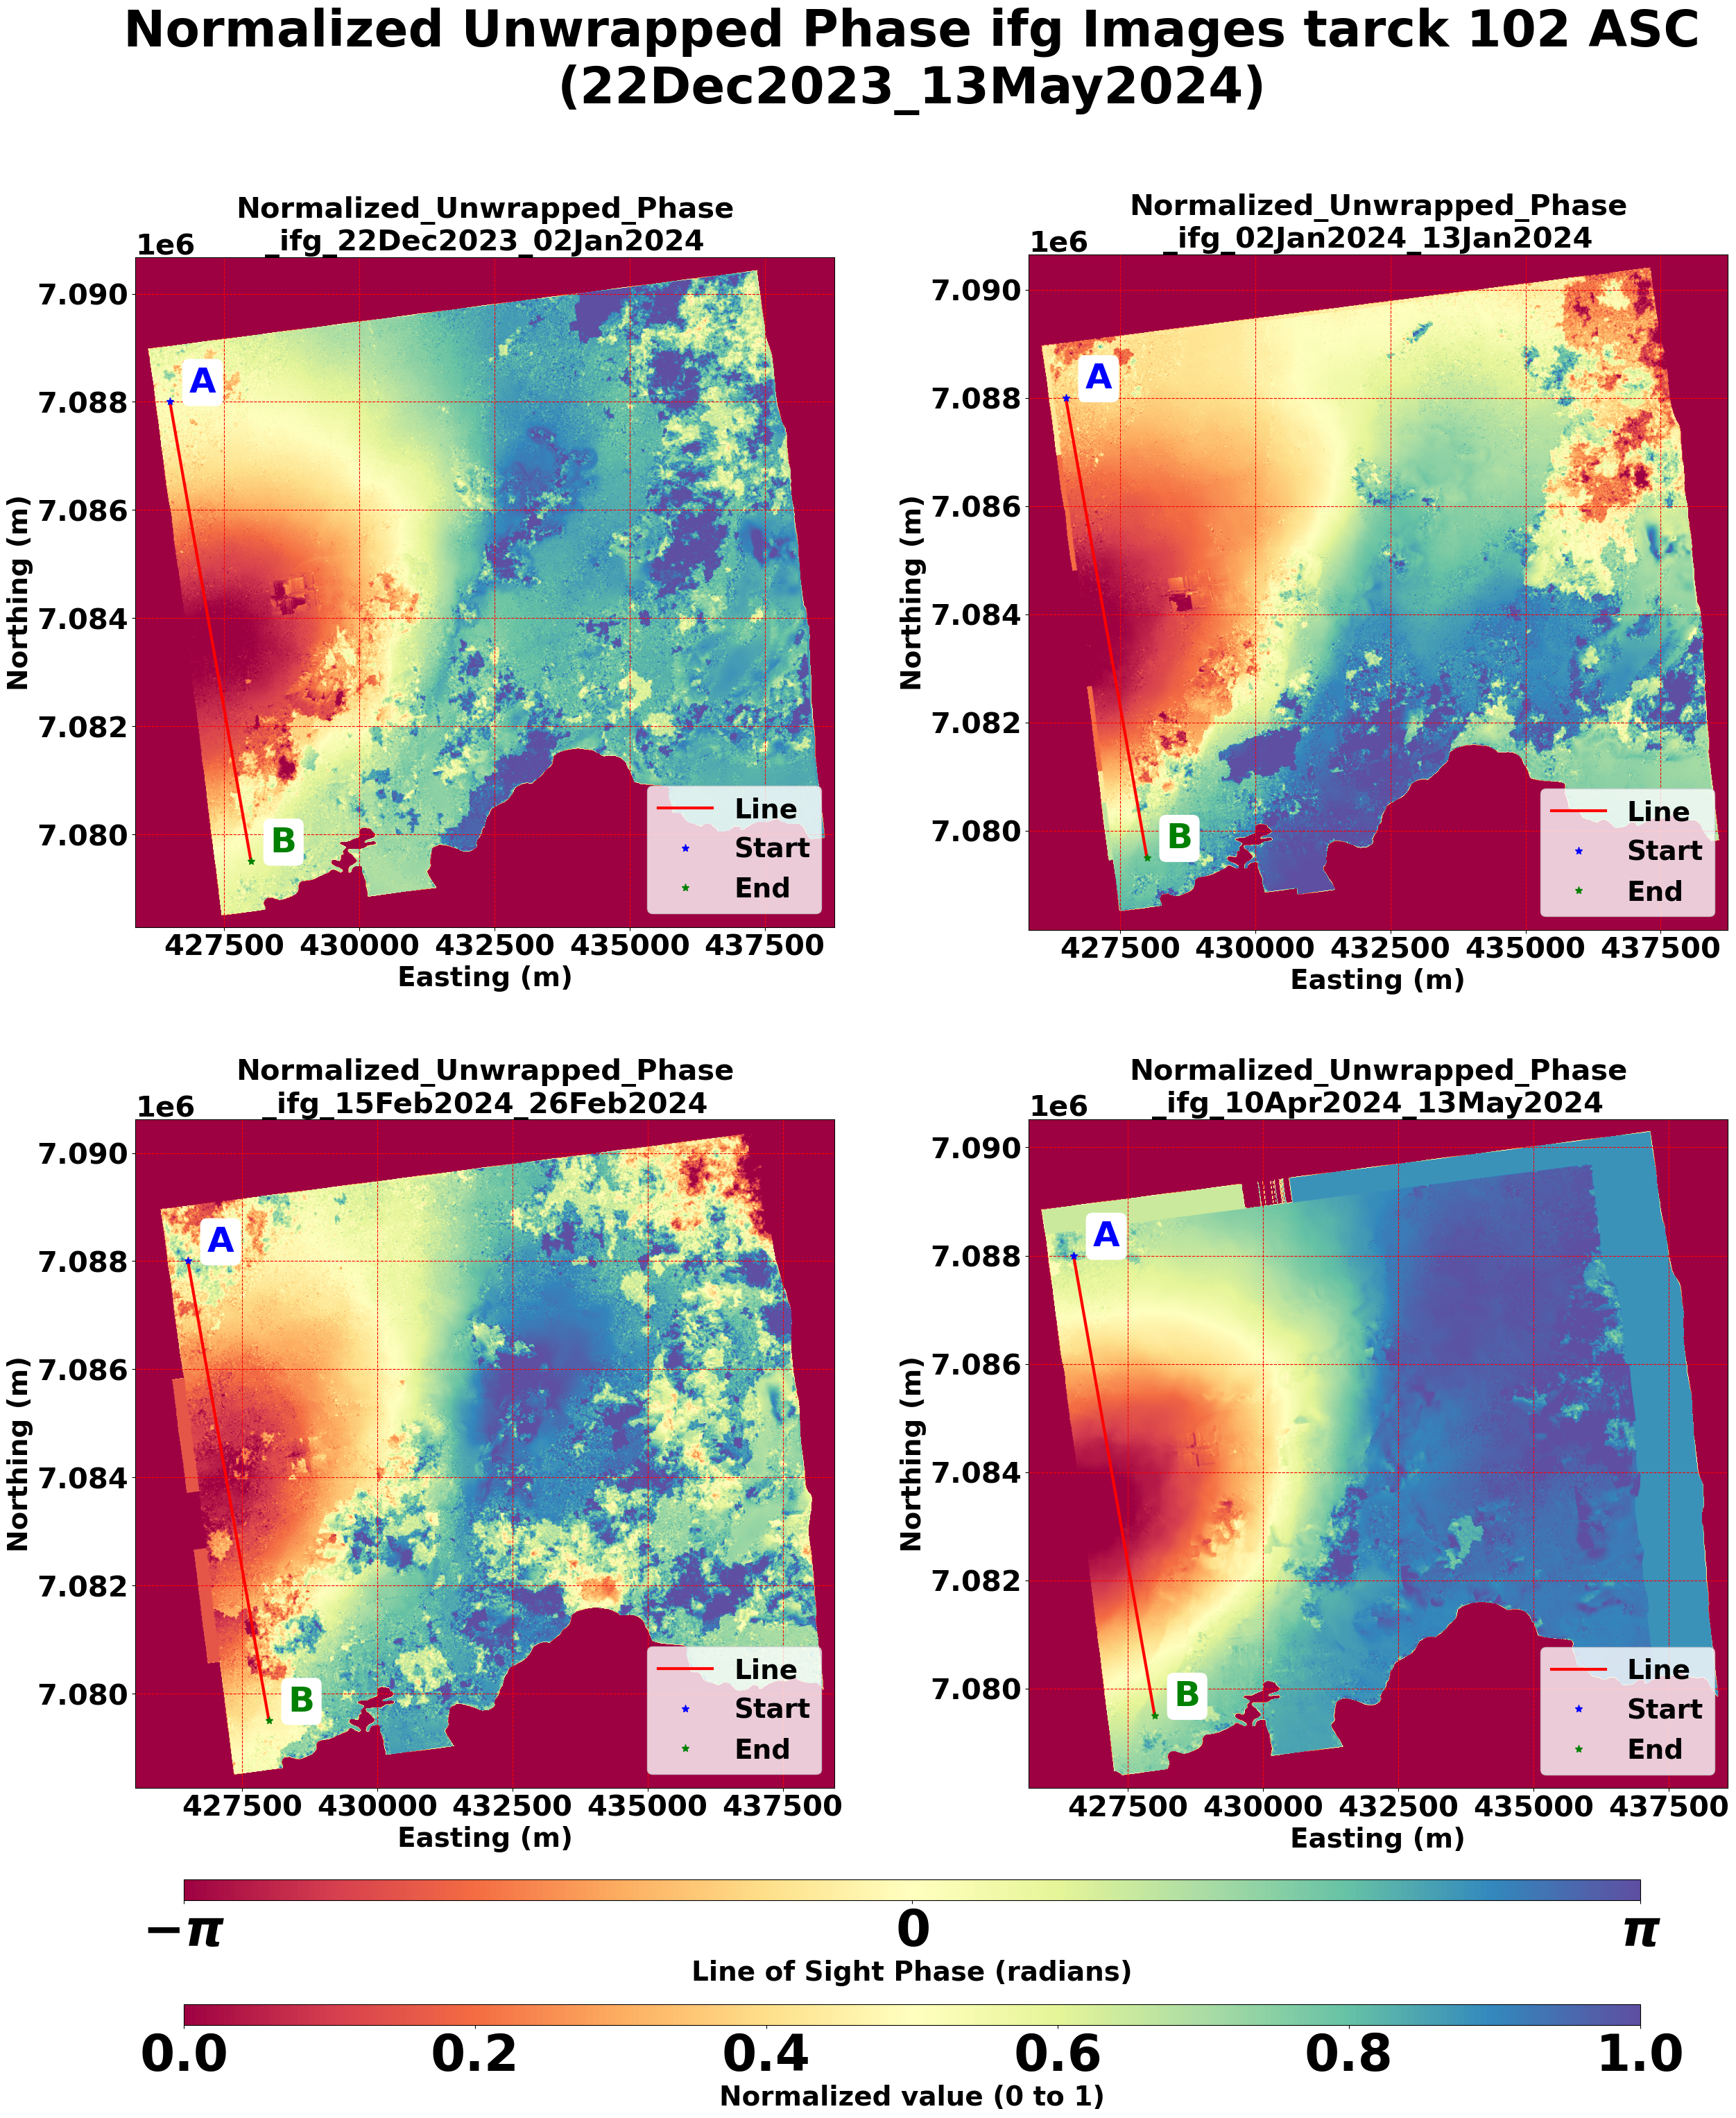

In [5]:
# Read the images
tif_paths = [
    "Normalized_Unw_Phase_ifg_22Dec2023_02Jan2024_27N.tif",
    "Normalized_Unw_Phase_ifg_02Jan2024_13Jan2024_27N.tif",
    "Normalized_Unw_Phase_ifg_15Feb2024_26Feb2024_27N.tif",
    "Normalized_Unw_Phase_ifg_10Apr2024_13May2024_27N.tif"
    # "coh_HH_22Dec2023_02Jan2024_27N.tif",
    # "coh_HH_02Jan2024_13Jan2024_27N.tif",
    # "coh_HH_15Feb2024_26Feb2024_27N.tif",
    # "coh_HH_10Apr2024_13May2024_27N.tif"
]
titles = [
    "Normalized_Unwrapped_Phase\n_ifg_22Dec2023_02Jan2024",
    "Normalized_Unwrapped_Phase\n_ifg_02Jan2024_13Jan2024",
    "Normalized_Unwrapped_Phase\n_ifg_15Feb2024_26Feb2024",
    "Normalized_Unwrapped_Phase\n_ifg_10Apr2024_13May2024"
    # "Coherence_map_\n22Dec2023_02Jan2024",
    # "Coherence_map_\n02Jan2024_13Jan2024",
    # "Coherence_map_\n15Feb2024_26Feb2024",
    # "Coherence_map_\n10Apr2024_13May2024"
]

# Read the images
images = [read_image(path) for path in tif_paths]

# Define start and end points in georeferenced coordinates (easting, northing)
start_point_geo = (426500, 7088000)  # Example: (easting, northing)
end_point_geo = (428000, 7079500)  # Example: (easting, northing)

# Extract row and column coordinates
rows = [start_point_geo[0], end_point_geo[0]]
cols = [start_point_geo[1], end_point_geo[1]]


print(f"Start Point (Easting, Northing): {start_point_geo}")
print(f"End Point (Easting, Northing): {end_point_geo}")


# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(30, 30))  # Adjust figsize as needed
#fig, axes = plt.subplots(3, 4, figsize=(35, 45))  # Adjust figsize as needed
axes = axes.flatten()

# Plot each image with georeferencing
for i, (ax, (image, transform, crs, bounds)) in enumerate(zip(axes, images)):
    # Plot the image with georeferencing
    # Choose colormap based on title or filename
    if "coh" in tif_paths[i].lower() or "coherence" in titles[i].lower():
        cmap = "gray"
    else:
        cmap = "Spectral"
    show(image, transform=transform, ax=ax, cmap=cmap)
    ax.set_title(titles[i],fontsize=30)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    # # Set axis labels based on CRS
    # if crs.is_geographic:
    #     ax.set_xlabel("Longitude")
    #     ax.set_ylabel("Latitude")
    # else:
    #     ax.set_xlabel("Easting (m)")
    #     ax.set_ylabel("Northing (m)")

    # Add gridlines
    ax.grid(color='red', linestyle='--', linewidth=0.8)

    # Plot the line between start and end points
    ax.plot([start_point_geo[0], end_point_geo[0]],[start_point_geo[1], end_point_geo[1]], 'r-', linewidth=3, label="Line")
    # Add markers at start and end points
    ax.plot(start_point_geo[0], start_point_geo[1],'b*', markersize=8, label="Start") # Blue marker
    ax.annotate('A', xy=(start_point_geo[0], start_point_geo[1]), xytext=(20, 10), 
            textcoords='offset points', fontsize=36, color='b',
               bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2'))
    ax.plot(end_point_geo[0], end_point_geo[1],'g*', markersize=8, label="End") # Green marker
    ax.annotate('B', xy=(end_point_geo[0], end_point_geo[1]), xytext=(20, 10), 
            textcoords='offset points', fontsize=36, color='g',
               bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2'))
    ax.legend(loc='lower right')

# Add a global colorbar for all images
# cbar_ax = fig.add_axes([0.91, 0.18, 0.015, 0.7])
# global_cbar = fig.colorbar(plt.cm.ScalarMappable(cmap="Spectral", norm=plt.Normalize(vmin=-np.pi, vmax=np.pi)), cax=cbar_ax)
# global_cbar.set_ticks([-np.pi, 0, np.pi])
# global_cbar.set_ticklabels([r'$-\pi$', r'$0$', r'$\pi$'])
# global_cbar.set_label("Line of Sight Phase (radians)", fontsize=14)

# cbar_ax1 = fig.add_axes([0.95, 0.18, 0.015, 0.7])
# global_cbar1 = fig.colorbar(plt.cm.ScalarMappable(cmap="Spectral", norm=plt.Normalize(0, 1)), cax=cbar_ax1, orientation='vertical')
# global_cbar1.set_label("Normalized value (0 to 1)", fontsize=14)

#cbar_ax2 = fig.add_axes([0.99, 0.18, 0.015, 0.7])
# cbar_ax2 = fig.add_axes([0.91, 0.18, 0.015, 0.7])
# global_cbar2 = fig.colorbar(plt.cm.ScalarMappable(cmap="gray", norm=plt.Normalize(0, 1)), cax=cbar_ax2)
# global_cbar2.set_label("Coherence value (0 to 1)", fontsize=14)

cbar_ax1 = fig.add_axes([0.15, 0.07, 0.7, 0.01])  # [left, bottom, width, height]
global_cbar1 = fig.colorbar(plt.cm.ScalarMappable(cmap="Spectral", norm=plt.Normalize(vmin=-np.pi, vmax=np.pi)), cax=cbar_ax1, orientation='horizontal')
# Define the ticks and tick labels
ticks = [-np.pi, 0, np.pi]  # Only three ticks: -π, 0, π
tick_labels = [r'$-\pi$', r'$0$', r'$\pi$']  # Corresponding labels

# Set the ticks and tick labels for the colorbar
global_cbar1.set_ticks(ticks)
global_cbar1.set_ticklabels(tick_labels)
global_cbar1.set_label("Line of Sight Phase (radians)",fontweight='bold')
global_cbar1.ax.tick_params(labelsize=52)

# # # Add a second colorbar for normalized data (0 to 1)
# #cbar_ax2 = fig.add_axes([0.945, 0.15, 0.02, 0.7])  # Position for the second colorbar
cbar_ax2 = fig.add_axes([0.15, 0.01, 0.7, 0.01])
global_cbar2 = fig.colorbar(plt.cm.ScalarMappable(cmap="Spectral", norm=plt.Normalize(0, 1)), cax=cbar_ax2, orientation='horizontal')
global_cbar2.set_label("Normalized value (0 to 1)",fontweight='bold')
global_cbar2.ax.tick_params(labelsize=52)

# # Add a second colorbar for normalized data (0 to 1)
 #cbar_ax3 = fig.add_axes([0.99, 0.15, 0.02, 0.7])  # Position for the second colorbar
 #cbar_ax3 = fig.add_axes([0.525, 0.01, 0.325, 0.01])
# cbar_ax3 = fig.add_axes([0.15, 0.01, 0.7, 0.01])
# global_cbar3 = fig.colorbar(plt.cm.ScalarMappable(cmap="gray", norm=plt.Normalize(0, 1)), cax=cbar_ax3, orientation='horizontal')
# global_cbar3.set_label("Coherence value (0 to 1)")
# global_cbar3.ax.tick_params(labelsize=52)



#Remove the last empty subplot
#fig.delaxes(axes[-1])

# Add a main title
fig.suptitle("Normalized Unwrapped Phase ifg Images tarck 102 ASC\n(22Dec2023_13May2024)", fontsize=52, fontweight='bold')
#fig.suptitle("Coherence map tarck 102 ASC (22Dec2023_13May2024)", fontsize=52, fontweight='bold')

# image3 = Image.open("unw+fault.png")

# plt.subplot(3, 3, (4,6))
# plt.imshow(image3)  # Keep original colors for the maps
# plt.title("Normalized_Unw_Phase_Ifg_22Dec2023_\n02Jan2024_with_Coh_Mask_and_Faults")
# plt.xlabel("Column Index")
# plt.ylabel("Row Index")
# plt.grid(color='red', linestyle='--', linewidth=0.5)

# tif_path_1 = "Normalized_Unw_Phase_ifg_22Dec2023_02Jan2024_27N.tif"
# tif_path_2 = "Normalized_Unw_Phase_ifg_02Jan2024_13Jan2024_27N.tif"
# tif_path_3 = "Normalized_Unw_Phase_ifg_15Feb2024_26Feb2024_27N.tif"
# tif_path_4 = "Normalized_Unw_Phase_ifg_10Apr2024_13May2024_27N.tif"
# tif_path_5 = "Normalized_Unw_Phase_ifg_04Jun2024_07Jul2024_27N.tif"

# # Extract profile lines from the normalized images
# line_values_1 = extract_normlized_line_profile(tif_path_1, start_point_geo, end_point_geo)
# line_values_2 = extract_normlized_line_profile(tif_path_2, start_point_geo, end_point_geo)
# line_values_3 = extract_normlized_line_profile(tif_path_3, start_point_geo, end_point_geo)
# line_values_4 = extract_normlized_line_profile(tif_path_4, start_point_geo, end_point_geo)


# # Plot the profile lines
# #plt.figure(figsize=(18, 4))
# plt.subplot(3, 2,(5,6))
# plt.plot(range(len(line_values_1)), line_values_1, color='blue', label="Normalized_Unw_Phase_ifg_22Dec2023_02Jan2024")
# plt.plot(range(len(line_values_2)), line_values_2, color='green', label= "Normalized_Unw_Phase_ifg_02Jan2024_13Jan2024")
# plt.plot(range(len(line_values_3)), line_values_3, color='red', label= "Normalized_Unw_Phase_ifg_15Feb2024_26Feb2024")
# plt.plot(range(len(line_values_4)), line_values_4, color='black', label= "Normalized_Unw_Phase_ifg_10Apr2024_13May2024")

# # Add 'A' at the start and 'B' at the end of the profile line
# plt.annotate('A', xy=(0, line_values_1[0]), xytext=(-40, -20), 
#              textcoords='offset points', fontsize=40, fontweight='bold', color='blue')
#             #bbox=dict(facecolor='red', edgecolor='none', boxstyle='round,pad=0.1'))
# plt.annotate('B', xy=(len(line_values_1)-1, line_values_1[-1]), xytext=(10, -8), 
#              textcoords='offset points', fontsize=40, fontweight='bold', color='g')
#             #bbox=dict(facecolor='red', edgecolor='none', boxstyle='round,pad=0.1'))

# plt.xlabel('Path in Pixels')
# plt.ylabel('Normalized Value')
# plt.title('Profile Plot for Unw Phase ifg track 102 ASC (22Dec2023_13May2024)')#,fontsize=20, fontweight='bold')
# plt.grid(True)
# plt.legend()

# # Add the legend with title
# legend = plt.legend(loc='lower center', title=f"start_point_geo={start_point_geo}\nend_point_geo={end_point_geo}")#,fontsize=14)

# Adjust layout
#plt.tight_layout(rect=[0, 0, 0.9, 0.99])

plt.tight_layout(rect=[0.05, 0.07, 0.92, 0.98])  # more padding for titles/colorbars

plt.rcParams.update({
    'font.size': 30,               # Base font size for all text
    'font.weight': 'bold',         # Global bold font
    'axes.titlesize': 28,          # Subplot titles
    'axes.labelsize': 28,          # Axis labels
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'xtick.labelsize': 40,         # Tick labels
    'ytick.labelsize': 40,
    'legend.fontsize': 28,
    'figure.titlesize': 42         # Main figure title
})

# Save the figure
#fig.savefig("Normalized_Unwrapped_Phase_Images_Track_102_ASC (22Dec2023_13May2024)_new.png", dpi=300, bbox_inches="tight")
#fig.savefig("Coherence_map_Images_Track_102_ASC (22Dec2023_13May2024)_new11.png", dpi=300, bbox_inches="tight")


plt.show()

Start Point (Easting, Northing): (426500, 7088000)
End Point (Easting, Northing): (428000, 7079500)


C:\Users\Mohannad Zahra\AppData\Local\Temp\ipykernel_18636\2828312615.py:155: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(3, 2,(5,6))
C:\Users\Mohannad Zahra\AppData\Local\Temp\ipykernel_18636\2828312615.py:181: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.05, 0.05, 0.92, 0.98])  # more padding for titles/colorbars


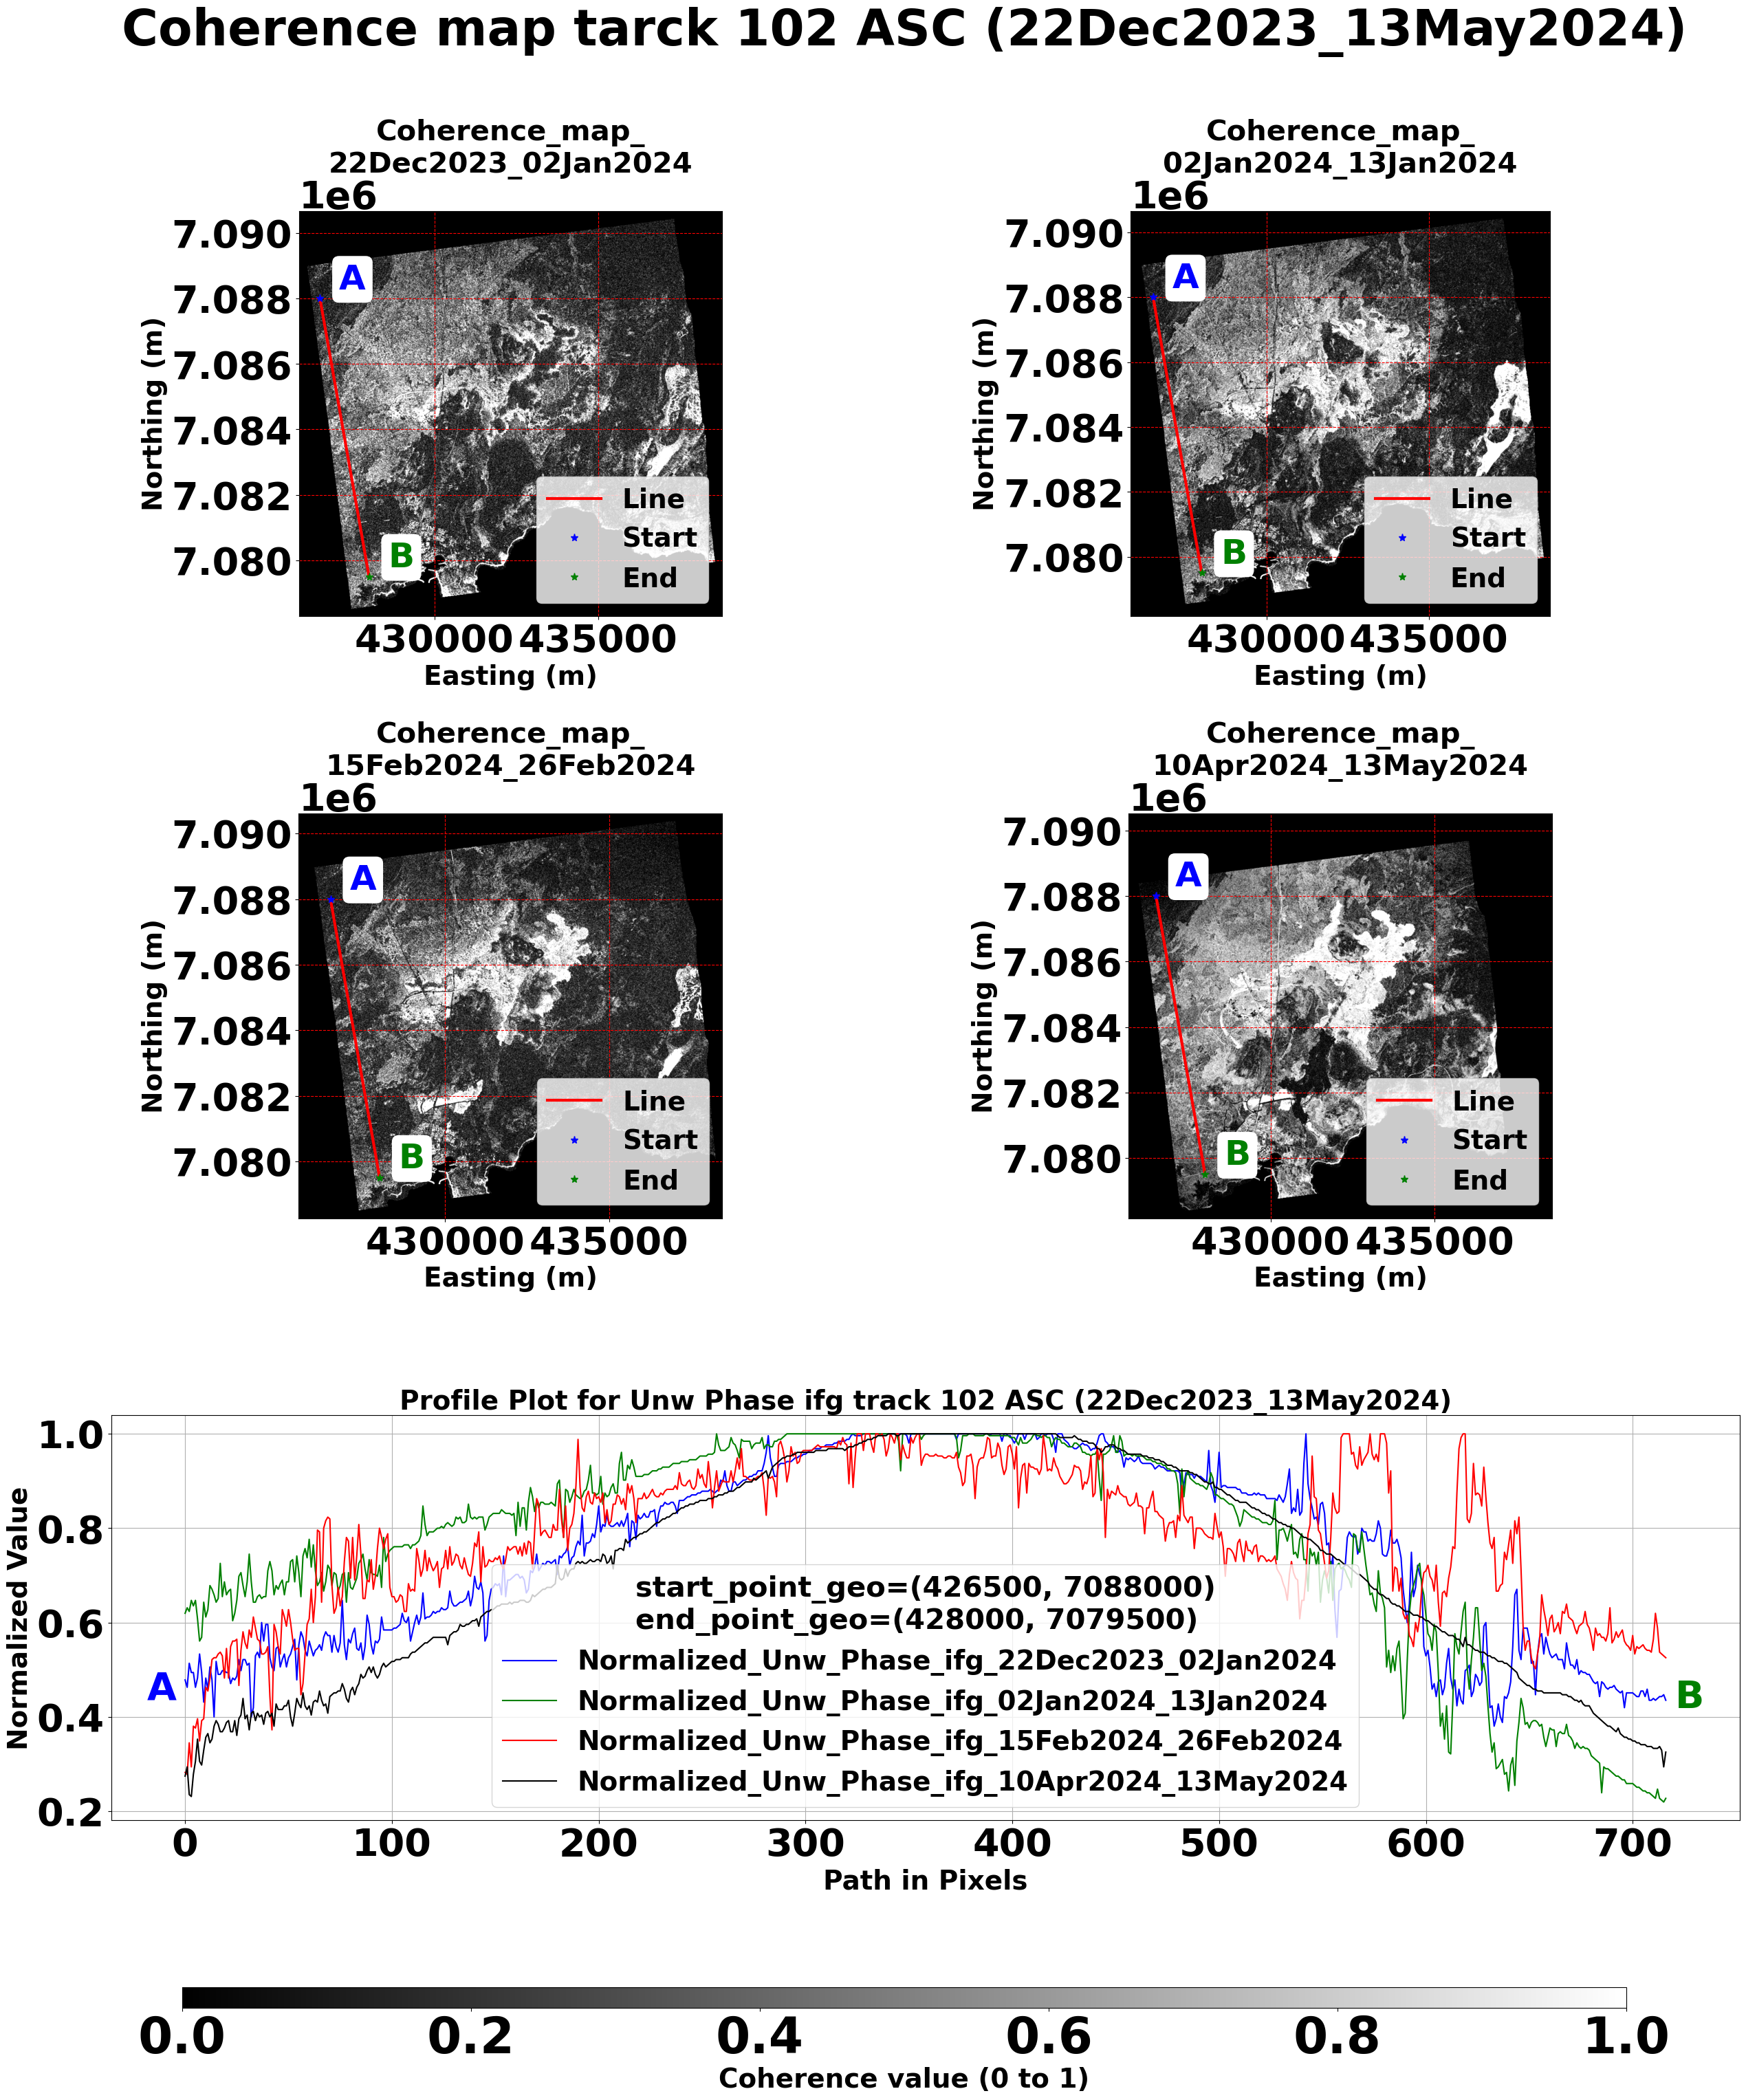

In [6]:
# Read the images
tif_paths = [
    # "Normalized_Unw_Phase_ifg_22Dec2023_02Jan2024_27N.tif",
    # "Normalized_Unw_Phase_ifg_02Jan2024_13Jan2024_27N.tif",
    # "Normalized_Unw_Phase_ifg_15Feb2024_26Feb2024_27N.tif",
    # "Normalized_Unw_Phase_ifg_10Apr2024_13May2024_27N.tif"
    "coh_HH_22Dec2023_02Jan2024_27N.tif",
    "coh_HH_02Jan2024_13Jan2024_27N.tif",
    "coh_HH_15Feb2024_26Feb2024_27N.tif",
    "coh_HH_10Apr2024_13May2024_27N.tif"
]
titles = [
    # "Normalized_Unwrapped_Phase\n_ifg_22Dec2023_02Jan2024",
    # "Normalized_Unwrapped_Phase\n_ifg_02Jan2024_13Jan2024",
    # "Normalized_Unwrapped_Phase\n_ifg_15Feb2024_26Feb2024",
    # "Normalized_Unwrapped_Phase\n_ifg_10Apr2024_13May2024"
    "Coherence_map_\n22Dec2023_02Jan2024",
    "Coherence_map_\n02Jan2024_13Jan2024",
    "Coherence_map_\n15Feb2024_26Feb2024",
    "Coherence_map_\n10Apr2024_13May2024"
]

# Read the images
images = [read_image(path) for path in tif_paths]

# Define start and end points in georeferenced coordinates (easting, northing)
start_point_geo = (426500, 7088000)  # Example: (easting, northing)
end_point_geo = (428000, 7079500)  # Example: (easting, northing)

# Extract row and column coordinates
rows = [start_point_geo[0], end_point_geo[0]]
cols = [start_point_geo[1], end_point_geo[1]]


print(f"Start Point (Easting, Northing): {start_point_geo}")
print(f"End Point (Easting, Northing): {end_point_geo}")


# Create subplots
fig, axes = plt.subplots(3, 2, figsize=(30, 30))  # Adjust figsize as needed
#fig, axes = plt.subplots(3, 4, figsize=(35, 45))  # Adjust figsize as needed
axes = axes.flatten()

# Plot each image with georeferencing
for i, (ax, (image, transform, crs, bounds)) in enumerate(zip(axes, images)):
    # Plot the image with georeferencing
    # Choose colormap based on title or filename
    if "coh" in tif_paths[i].lower() or "coherence" in titles[i].lower():
        cmap = "gray"
    else:
        cmap = "Spectral"
    show(image, transform=transform, ax=ax, cmap=cmap)
    ax.set_title(titles[i],fontsize=30)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    # # Set axis labels based on CRS
    # if crs.is_geographic:
    #     ax.set_xlabel("Longitude")
    #     ax.set_ylabel("Latitude")
    # else:
    #     ax.set_xlabel("Easting (m)")
    #     ax.set_ylabel("Northing (m)")

    # Add gridlines
    ax.grid(color='red', linestyle='--', linewidth=0.8)

    # Plot the line between start and end points
    ax.plot([start_point_geo[0], end_point_geo[0]],[start_point_geo[1], end_point_geo[1]], 'r-', linewidth=3, label="Line")
    # Add markers at start and end points
    ax.plot(start_point_geo[0], start_point_geo[1],'b*', markersize=8, label="Start") # Blue marker
    ax.annotate('A', xy=(start_point_geo[0], start_point_geo[1]), xytext=(20, 10), 
            textcoords='offset points', fontsize=36, color='b',
               bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2'))
    ax.plot(end_point_geo[0], end_point_geo[1],'g*', markersize=8, label="End") # Green marker
    ax.annotate('B', xy=(end_point_geo[0], end_point_geo[1]), xytext=(20, 10), 
            textcoords='offset points', fontsize=36, color='g',
               bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2'))
    ax.legend(loc='lower right')

# Add a global colorbar for all images
# cbar_ax = fig.add_axes([0.91, 0.18, 0.015, 0.7])
# global_cbar = fig.colorbar(plt.cm.ScalarMappable(cmap="Spectral", norm=plt.Normalize(vmin=-np.pi, vmax=np.pi)), cax=cbar_ax)
# global_cbar.set_ticks([-np.pi, 0, np.pi])
# global_cbar.set_ticklabels([r'$-\pi$', r'$0$', r'$\pi$'])
# global_cbar.set_label("Line of Sight Phase (radians)", fontsize=14)

# cbar_ax1 = fig.add_axes([0.95, 0.18, 0.015, 0.7])
# global_cbar1 = fig.colorbar(plt.cm.ScalarMappable(cmap="Spectral", norm=plt.Normalize(0, 1)), cax=cbar_ax1, orientation='vertical')
# global_cbar1.set_label("Normalized value (0 to 1)", fontsize=14)

#cbar_ax2 = fig.add_axes([0.99, 0.18, 0.015, 0.7])
# cbar_ax2 = fig.add_axes([0.91, 0.18, 0.015, 0.7])
# global_cbar2 = fig.colorbar(plt.cm.ScalarMappable(cmap="gray", norm=plt.Normalize(0, 1)), cax=cbar_ax2)
# global_cbar2.set_label("Coherence value (0 to 1)", fontsize=14)

# cbar_ax1 = fig.add_axes([0.15, 0.01, 0.7, 0.01])  # [left, bottom, width, height]
# global_cbar1 = fig.colorbar(plt.cm.ScalarMappable(cmap="Spectral", norm=plt.Normalize(vmin=-np.pi, vmax=np.pi)), cax=cbar_ax1, orientation='horizontal')
# # Define the ticks and tick labels
# ticks = [-np.pi, 0, np.pi]  # Only three ticks: -π, 0, π
# tick_labels = [r'$-\pi$', r'$0$', r'$\pi$']  # Corresponding labels

# # Set the ticks and tick labels for the colorbar
# global_cbar1.set_ticks(ticks)
# global_cbar1.set_ticklabels(tick_labels)
# global_cbar1.set_label("Line of Sight Phase (radians)",fontweight='bold')

# # # Add a second colorbar for normalized data (0 to 1)
# #cbar_ax2 = fig.add_axes([0.945, 0.15, 0.02, 0.7])  # Position for the second colorbar
# cbar_ax2 = fig.add_axes([0.15, 0.07, 0.7, 0.01])
# global_cbar2 = fig.colorbar(plt.cm.ScalarMappable(cmap="Spectral", norm=plt.Normalize(0, 1)), cax=cbar_ax2, orientation='horizontal')
# global_cbar2.set_label("Normalized value (0 to 1)",fontweight='bold')


# # Add a second colorbar for normalized data (0 to 1)
 #cbar_ax3 = fig.add_axes([0.99, 0.15, 0.02, 0.7])  # Position for the second colorbar
 #cbar_ax3 = fig.add_axes([0.525, 0.01, 0.325, 0.01])
cbar_ax3 = fig.add_axes([0.15, 0.01, 0.7, 0.01])
global_cbar3 = fig.colorbar(plt.cm.ScalarMappable(cmap="gray", norm=plt.Normalize(0, 1)), cax=cbar_ax3, orientation='horizontal')
global_cbar3.set_label("Coherence value (0 to 1)")
global_cbar3.ax.tick_params(labelsize=52)



#Remove the last empty subplot
#fig.delaxes(axes[-1])

# Add a main title
#fig.suptitle("Normalized Unwrapped Phase ifg Images tarck 102 ASC\n(22Dec2023_13May2024)", fontsize=52, fontweight='bold')
fig.suptitle("Coherence map tarck 102 ASC (22Dec2023_13May2024)", fontsize=52, fontweight='bold')

# image3 = Image.open("unw+fault.png")

# plt.subplot(3, 3, (4,6))
# plt.imshow(image3)  # Keep original colors for the maps
# plt.title("Normalized_Unw_Phase_Ifg_22Dec2023_\n02Jan2024_with_Coh_Mask_and_Faults")
# plt.xlabel("Column Index")
# plt.ylabel("Row Index")
# plt.grid(color='red', linestyle='--', linewidth=0.5)

tif_path_1 = "Normalized_Unw_Phase_ifg_22Dec2023_02Jan2024_27N.tif"
tif_path_2 = "Normalized_Unw_Phase_ifg_02Jan2024_13Jan2024_27N.tif"
tif_path_3 = "Normalized_Unw_Phase_ifg_15Feb2024_26Feb2024_27N.tif"
tif_path_4 = "Normalized_Unw_Phase_ifg_10Apr2024_13May2024_27N.tif"
tif_path_5 = "Normalized_Unw_Phase_ifg_04Jun2024_07Jul2024_27N.tif"

# Extract profile lines from the normalized images
line_values_1 = extract_normlized_line_profile(tif_path_1, start_point_geo, end_point_geo)
line_values_2 = extract_normlized_line_profile(tif_path_2, start_point_geo, end_point_geo)
line_values_3 = extract_normlized_line_profile(tif_path_3, start_point_geo, end_point_geo)
line_values_4 = extract_normlized_line_profile(tif_path_4, start_point_geo, end_point_geo)


# Plot the profile lines
#plt.figure(figsize=(18, 4))
plt.subplot(3, 2,(5,6))
plt.plot(range(len(line_values_1)), line_values_1, color='blue', label="Normalized_Unw_Phase_ifg_22Dec2023_02Jan2024")
plt.plot(range(len(line_values_2)), line_values_2, color='green', label= "Normalized_Unw_Phase_ifg_02Jan2024_13Jan2024")
plt.plot(range(len(line_values_3)), line_values_3, color='red', label= "Normalized_Unw_Phase_ifg_15Feb2024_26Feb2024")
plt.plot(range(len(line_values_4)), line_values_4, color='black', label= "Normalized_Unw_Phase_ifg_10Apr2024_13May2024")

# Add 'A' at the start and 'B' at the end of the profile line
plt.annotate('A', xy=(0, line_values_1[0]), xytext=(-40, -20), 
             textcoords='offset points', fontsize=40, fontweight='bold', color='blue')
            #bbox=dict(facecolor='red', edgecolor='none', boxstyle='round,pad=0.1'))
plt.annotate('B', xy=(len(line_values_1)-1, line_values_1[-1]), xytext=(10, -8), 
             textcoords='offset points', fontsize=40, fontweight='bold', color='g')
            #bbox=dict(facecolor='red', edgecolor='none', boxstyle='round,pad=0.1'))

plt.xlabel('Path in Pixels')
plt.ylabel('Normalized Value')
plt.title('Profile Plot for Unw Phase ifg track 102 ASC (22Dec2023_13May2024)')#,fontsize=20, fontweight='bold')
plt.grid(True)
plt.legend()

# Add the legend with title
legend = plt.legend(loc='lower center', title=f"start_point_geo={start_point_geo}\nend_point_geo={end_point_geo}")#,fontsize=14)

# Adjust layout
#plt.tight_layout(rect=[0, 0, 0.9, 0.99])

plt.tight_layout(rect=[0.05, 0.05, 0.92, 0.98])  # more padding for titles/colorbars

plt.rcParams.update({
    'font.size': 30,               # Base font size for all text
    'font.weight': 'bold',         # Global bold font
    'axes.titlesize': 28,          # Subplot titles
    'axes.labelsize': 28,          # Axis labels
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'xtick.labelsize': 30,         # Tick labels
    'ytick.labelsize': 30,
    'legend.fontsize': 28,
    'figure.titlesize': 42         # Main figure title
})

# Save the figure
#fig.savefig("Normalized_Unwrapped_Phase_Images_Track_102_ASC (22Dec2023_13May2024)_new.png", dpi=300, bbox_inches="tight")
#fig.savefig("Coherence_map_Images_Track_102_ASC (22Dec2023_13May2024)_new11.png", dpi=300, bbox_inches="tight")


plt.show()